In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df = pd.read_csv("data/homeprices_banglore.csv")
df.head()

,area,bedrooms,price
0,1056,2,39.07
1,2600,4,120.00
2,1440,3,62.00
3,1521,3,75.00
4,1200,2,51.00


In [3]:
df.shape

(20, 3)

In [4]:
df.columns

Index(['area', 'bedrooms', 'price'], dtype='str')

In [6]:
df.isna().sum()

area        0
bedrooms    0
price       0
dtype: int64

In [7]:
from sklearn import preprocessing

sx = preprocessing.MinMaxScaler()
sy = preprocessing.MinMaxScaler()

scaled_x = sx.fit_transform(df.drop("price", axis="columns"))
scaled_x

array([[0.08827586, 0.25      ],
       [0.62068966, 0.75      ],
       [0.22068966, 0.5       ],
       [0.24862069, 0.5       ],
       [0.13793103, 0.25      ],
       [0.12758621, 0.25      ],
       [0.6662069 , 0.75      ],
       [0.86206897, 0.75      ],
       [0.17586207, 0.5       ],
       [1.        , 1.        ],
       [0.34482759, 0.5       ],
       [0.68448276, 0.75      ],
       [0.06896552, 0.25      ],
       [0.10344828, 0.25      ],
       [0.5       , 0.5       ],
       [0.12931034, 0.25      ],
       [0.13103448, 0.5       ],
       [0.25517241, 0.5       ],
       [0.67931034, 0.5       ],
       [0.        , 0.        ]])

In [8]:
scaled_y = sy.fit_transform(df[["price"]].values.reshape(df.shape[0], 1))
scaled_y

array([[0.05237037],
       [0.65185185],
       [0.22222222],
       [0.31851852],
       [0.14074074],
       [0.04444444],
       [0.76296296],
       [0.91111111],
       [0.13333333],
       [1.        ],
       [0.37037037],
       [0.8       ],
       [0.04444444],
       [0.05925926],
       [0.51111111],
       [0.07407407],
       [0.11851852],
       [0.20740741],
       [0.51851852],
       [0.        ]])

In [16]:
def batch_gradient_descent(x, y_true, epochs, learning_rate=0.01):
    number_of_features = x.shape[1]
    w = np.ones(shape=(number_of_features))
    b = 0
    cost = 0
    total_samples = x.shape[0]

    cost_list = []
    epoch_list = []

    for i in range(epochs):
        y_predicted = np.dot(w, scaled_x.T) + b
        w_grad = -(2 / total_samples) * (x.T.dot(y_true - y_predicted))
        b_grad = -(2 / total_samples) * np.sum(y_true - y_predicted)
        w = w - learning_rate * w_grad
        b = b - learning_rate * b_grad
        cost = np.mean(np.square(y_true - y_predicted))
        if i % 10 == 0:
            cost_list.append(cost)
            epoch_list.append(i)
            # print(f"Epoch {i} : w = {w}, b = {b}, cost = {cost}")
    return w, b, cost, cost_list, epoch_list

In [18]:
w, b, cost, cost_list, epoch_list = batch_gradient_descent(
    scaled_x,
    scaled_y.reshape(
        scaled_y.shape[0],
    ),
    epochs=500,
)
w, b, cost

(array([0.70712464, 0.67456527]),
 np.float64(-0.23034857438407422),
 np.float64(0.0068641890429808105))

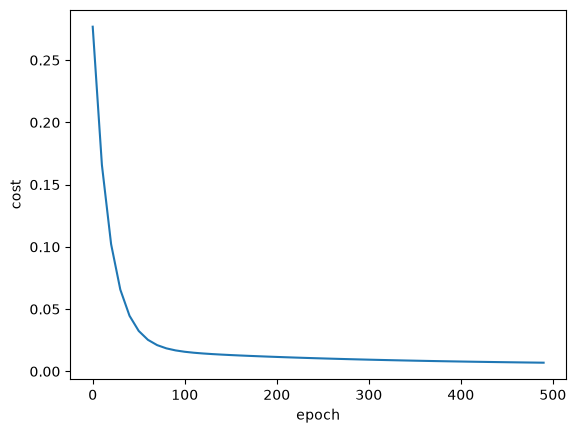

In [19]:
plt.xlabel("epoch")
plt.ylabel("cost")
plt.plot(epoch_list, cost_list)

In [22]:
def predic(area, bedrooms, w, b):
    scaled_x = sx.transform([[area, bedrooms]])[0]
    scaled_price = w[0] * scaled_x[0] + w[1] * scaled_x[1] + b
    return sy.inverse_transform([[scaled_price]])


predicted_price = predic(2600, 4, w, b)
predicted_price

d:\Python\TensorFlow\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


array([[128.45484403]])

In [28]:
import random


def stochastic_gradient_descent(x, y_true, epochs, learning_rate=0.01):
    number_of_features = x.shape[1]
    w = np.ones(shape=(number_of_features))
    b = 0
    cost = 0
    total_samples = x.shape[0]

    cost_list = []
    epoch_list = []

    for i in range(epochs):
        random_index = random.randint(0, total_samples - 1)
        sample_x = x[random_index]
        sample_y = y_true[random_index]
        y_predicted = np.dot(w, sample_x.T) + b
        w_grad = -(2 / total_samples) * (sample_x.T.dot(sample_y - y_predicted))
        b_grad = -(2 / total_samples) * np.sum(sample_y - y_predicted)
        w = w - learning_rate * w_grad
        b = b - learning_rate * b_grad
        cost = np.mean(np.square(sample_y - y_predicted))
        if i % 10 == 0:
            cost_list.append(cost)
            epoch_list.append(i)
    return w, b, cost, cost_list, epoch_list


w_sgd, b_sgd, cost_sgd, cost_list_sgd, epoch_list_sgd = stochastic_gradient_descent(
    scaled_x, scaled_y.reshape(scaled_y.shape[0]), epochs=500
)
w_sgd, b_sgd, cost_sgd

(array([0.91499098, 0.89840363]),
 np.float64(-0.16943755525760837),
 np.float64(0.05129698114560862))

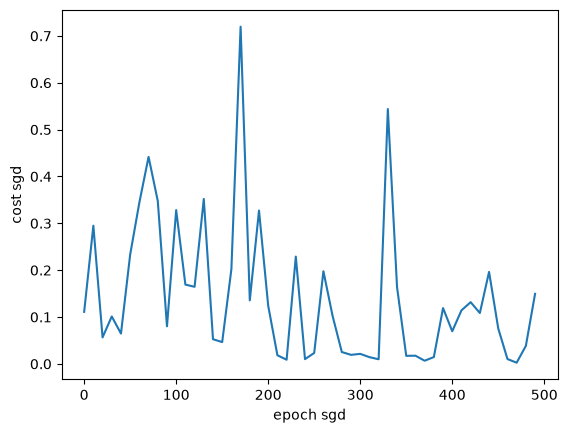

In [29]:
plt.xlabel("epoch sgd")
plt.ylabel("cost sgd")
plt.plot(epoch_list_sgd, cost_list_sgd)

In [32]:
predicted_price = predic(2600, 4, w, b)
predicted_price_sgd = predic(2600, 4, w_sgd, b_sgd)
predicted_price_sgd, predicted_price

d:\Python\TensorFlow\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
d:\Python\TensorFlow\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


(array([[176.75923097]]), array([[128.45484403]]))